# vexcel_masker — demo

Pull Vexcel **oblique**, **ortho**, and **DSM** imagery for a location, plus the
**parcel** and **building-footprint** polygons, and **mask** the imagery to
either one.

* An **ortho** is flattened onto the ground (like a map) — masking is a simple
  polygon cut-out.
* An **oblique** is a tilted, perspective view — a tall neighbour leans over the
  property line, so we ray-cast every pixel against the DSM height map and keep
  it only if the point it actually sees is inside the polygon.

Run the cells top to bottom. First copy `config.example.ini` to `config.ini` and
put your Vexcel username/password in it.

In [4]:
import vexcel_masker as vm

# Logs in with the username/password in config.ini and returns a ~24h token.
token = vm.get_token_from_config("config.ini")

# (Alternatively, paste a token directly:)
# token = "PASTE_TOKEN_HERE"
print("logged in")

logged in


## 1. Pick a location and get its polygons

Coordinates are `lon, lat` (x, y in degrees).

In [5]:
lon, lat = -76.876653, 38.757577   # a home near Upper Marlboro, MD

parcel     = vm.get_parcel(token, lon, lat)       # the property boundary
structures = vm.get_structures(token, lon, lat)   # building footprints on it
print("parcel:", parcel.geom_type, "| structures:", len(structures))

parcel: MultiPolygon | structures: 2


## 2. Fetch the three image layers — all from the same flight

`best_collection` finds the most recent dated collection that has the oblique,
DSM **and** ortho together, so the layers match in date. We pass it to each
`get_*` call.

In [6]:
collection = vm.best_collection(token, lon, lat)
print("collection:", collection)

dsm   = vm.get_dsm(token, lon, lat, collection=collection)
ortho = vm.get_ortho(token, lon, lat, collection=collection)
north = vm.get_oriented(token, lon, lat, "north", collection=collection)

print("dsm  :", dsm.data.shape, dsm.crs)
print("ortho:", ortho.image.shape)
print("north oblique:", north.image.shape, "captured", north.date)

collection: us-md-washington-2023
dsm  : (1021, 1021) EPSG:32618
ortho: (1200, 1200, 3)
north oblique: (2082, 2081, 3) captured 2023-09-02


## 3. Mask the OBLIQUE — to the parcel, then to just the buildings

`fill` can be a colour name, an `(R, G, B)` tuple, or `"average"` (mean image colour).

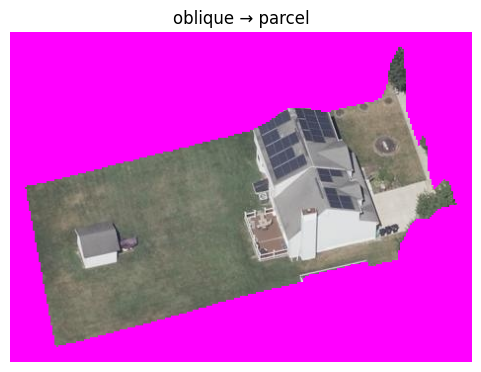

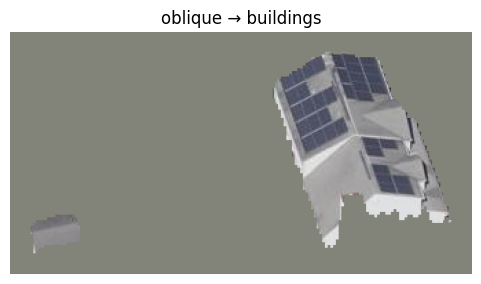

In [7]:
vm.show(vm.mask_oblique(north, dsm, parcel,     fill="magenta"),  "oblique → parcel")
vm.show(vm.mask_oblique(north, dsm, structures, fill="average"),  "oblique → buildings")

## 4. Mask the ORTHO — same two polygons

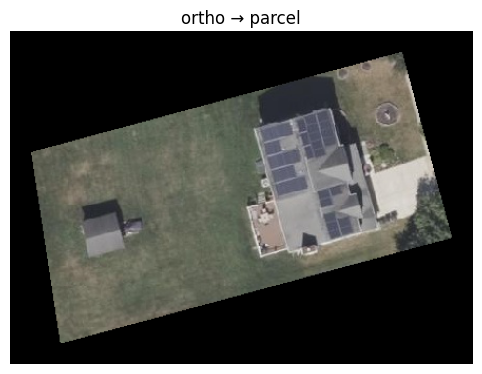

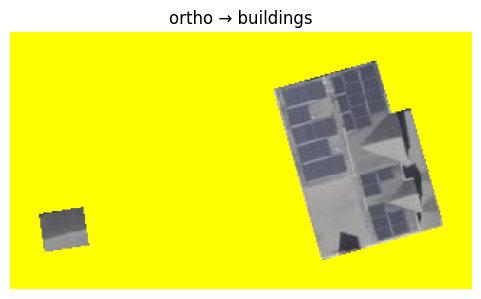

In [8]:
vm.show(vm.mask_ortho(ortho, parcel,     fill="black"),        "ortho → parcel")
vm.show(vm.mask_ortho(ortho, structures, fill=(255, 255, 0)),  "ortho → buildings")

## 4b. Outline instead of mask — check alignment on one image

Rather than hiding everything outside the polygon, draw just the **boundary
line** on the real image. Great for confirming the parcel/building lines up.
Default colour is magenta; `color=` and `thickness=` are adjustable.

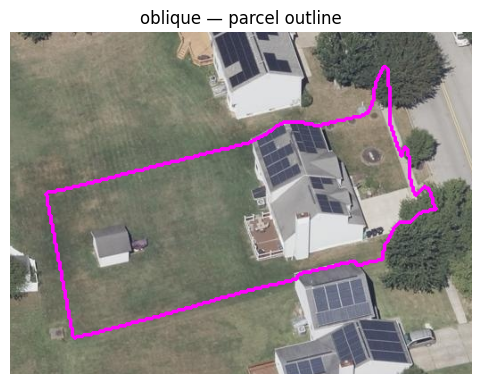

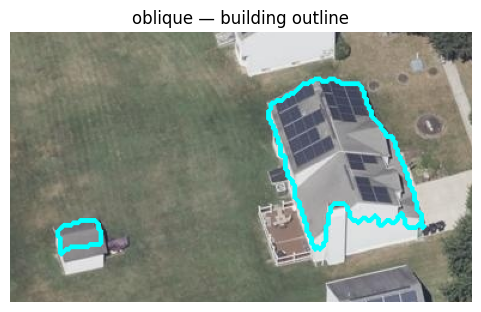

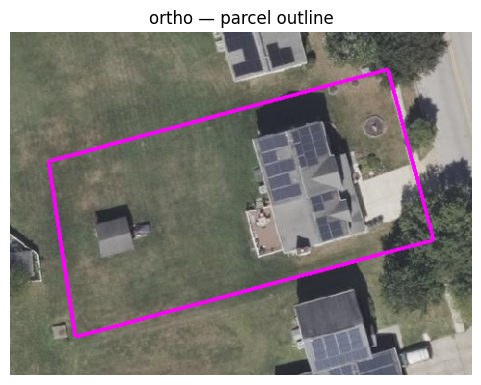

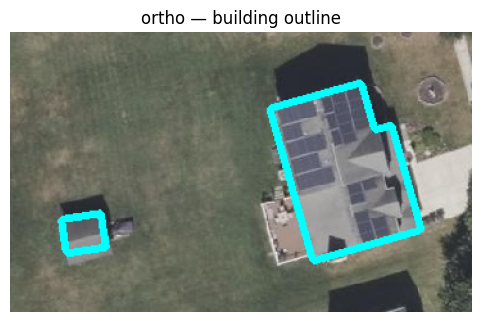

In [9]:
vm.show(vm.outline_oblique(north, dsm, parcel),              "oblique — parcel outline")
vm.show(vm.outline_oblique(north, dsm, structures, color="cyan"), "oblique — building outline")
vm.show(vm.outline_ortho(ortho, parcel),                     "ortho — parcel outline")
vm.show(vm.outline_ortho(ortho, structures, color="cyan", thickness=3), "ortho — building outline")

## 4c. Dilate — grow or shrink the polygon (in feet)

Add `dilate=<feet>` to any mask/outline call to buffer the polygon outward
(positive) or inward (negative) by that many **true ground feet**. Handy for
capturing eaves/overhang around a building, or trimming a parcel edge. It's
measured on the ground, so it behaves the same on obliques and orthos.

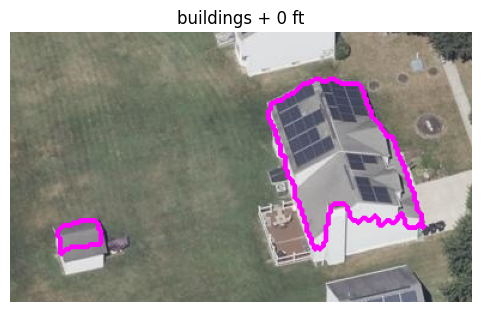

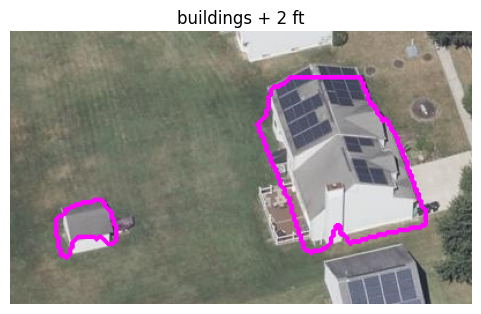

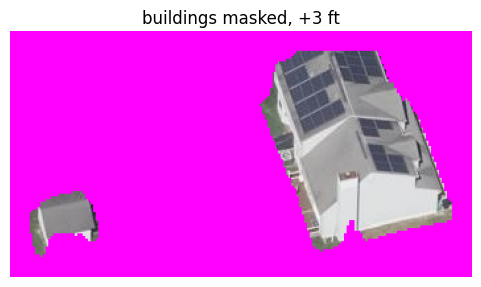

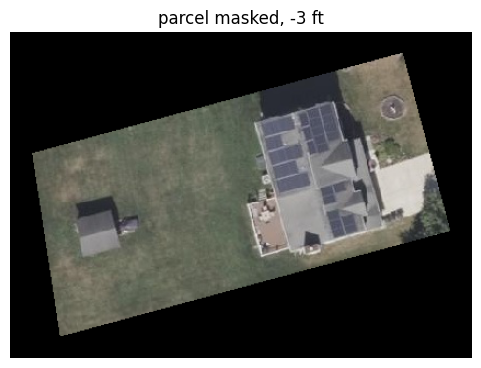

In [15]:
# outline the buildings at 0 ft vs +2 ft on the oblique
vm.show(vm.outline_oblique(north, dsm, structures, dilate=0),  "buildings + 0 ft")
vm.show(vm.outline_oblique(north, dsm, structures, dilate=3), "buildings + 2 ft")

# dilate also works on the mask, on the ortho, and negative (shrink)
vm.show(vm.mask_oblique(north, dsm, structures, dilate=3, fill="magenta"), "buildings masked, +3 ft")
vm.show(vm.mask_ortho(ortho, parcel, dilate=-3, fill="black"),             "parcel masked, -3 ft")

## 5. All four cardinal oblique directions, masked to the parcel

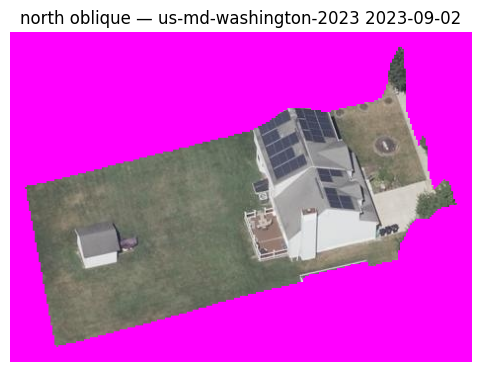

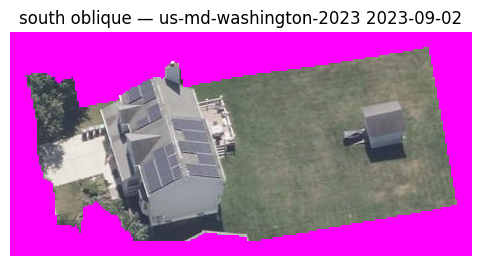

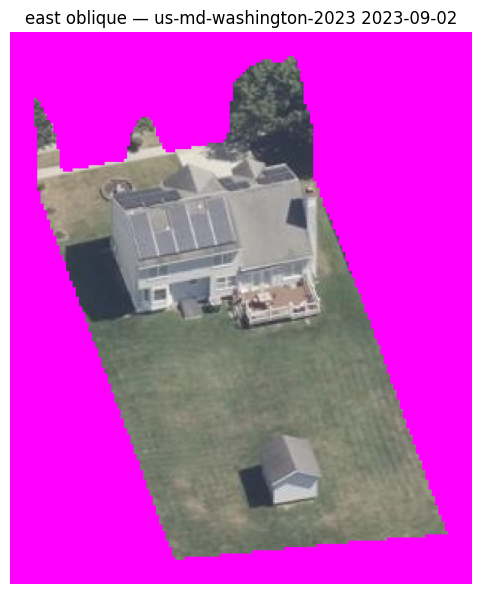

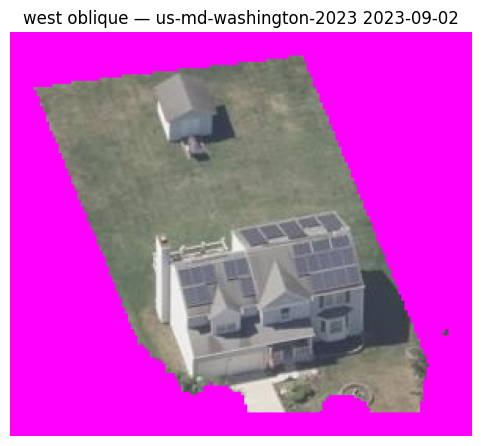

In [11]:
for d in ["north", "south", "east", "west"]:
    obl = vm.get_oriented(token, lon, lat, d, collection=collection)
    vm.show(vm.mask_oblique(obl, dsm, parcel, fill="magenta"),
            f"{d} oblique — {obl.collection} {obl.date}")

## 6. Batch over all the test points → save images to `out/`

For each location we save the oblique and ortho, masked to both the parcel and
the buildings.

In [12]:
import os
os.makedirs("out", exist_ok=True)

POINTS = [
    ("new_haven_ct",    -72.962240, 41.520105),
    ("hoa_lake_fl",     -82.611281, 28.047484),
    ("tampa_home_fl",   -82.602251, 28.053774),
    ("plant_city_fl",   -82.242645, 27.944225),
    ("tampa_area_fl",   -82.226839, 27.924763),
    ("miami_fl",        -80.229291, 25.748431),
    ("marlboro_md",     -76.876653, 38.757577),
]

for name, x, y in POINTS:
    try:
        coll   = vm.best_collection(token, x, y)
        parc   = vm.get_parcel(token, x, y)
        strs   = vm.get_structures(token, x, y)
        d      = vm.get_dsm(token, x, y, collection=coll)
        o      = vm.get_ortho(token, x, y, collection=coll)
        obl    = vm.get_oriented(token, x, y, "north", collection=coll)

        vm.save(vm.mask_oblique(obl, d, parc, fill="magenta"),  f"out/{name}_oblique_parcel.png")
        vm.save(vm.mask_oblique(obl, d, strs, fill="magenta"),  f"out/{name}_oblique_buildings.png")
        vm.save(vm.mask_ortho(o, parc, fill="black"),           f"out/{name}_ortho_parcel.png")
        vm.save(vm.mask_ortho(o, strs, fill="black"),           f"out/{name}_ortho_buildings.png")
        print(f"{name:16s} ok  ({coll})")
    except Exception as e:
        print(f"{name:16s} FAILED: {e}")

KeyboardInterrupt: 

## Options recap

* **What to mask to:** pass `parcel` or `structures` to `mask_oblique` / `mask_ortho`.
* **Fill:** `"magenta"`, `"black"`, `"cyan"`, `"green"`, `"white"`, `"red"`,
  an `(R, G, B)` tuple, or `"average"`.
* **Direction:** `get_oriented(..., "north"|"south"|"east"|"west")`.
* **Zoom / size:** `get_oriented(..., downsample=0)` = full resolution (1 = half,
  2 = quarter); `radius_m` sets the oblique crop; `size_m` sets the DSM/ortho box.
* **Edges:** `mask_oblique(..., ray_step=1)` gives the most precise mask edges
  (slower); larger `ray_step` is faster.